In [1]:
import pandas as pd

fake_df = pd.read_csv('Fake.csv')
real_df = pd.read_csv('True.csv')

# Real: 0 and Fake: 1
fake_df['label'] = 1
real_df['label'] = 0

df = pd.concat([real_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
df.head()

Dataset Shape: (44898, 5)

Class Distribution:
label
1    23481
0    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1


In [2]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [3]:
import re
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stopWords = set(stopwords.words('english'))

def clean_and_tokenization(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove HTML
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and numbers
    translator = str.maketrans('', '', string.punctuation + string.digits)
    text = text.translate(translator)
    # tokenization
    tokens = text.split()
    cleanedTokens = [word for word in tokens if word not in stopWords]

    return " ".join(cleanedTokens)

def strip_datelines(text):
    # Removes 'WASHINGTON (Reuters) - ' or similar datelines
    return re.sub(r'^[A-Z\s]+ \((Reuters|AP|AFP)\)\s*-\s*', '', text, flags=re.IGNORECASE)
    
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['full_text'] = df['title'] + " " + df['text']
df['full_text'] = df['full_text'].apply(strip_datelines)
df['cleanedText'] = df['full_text'].apply(clean_and_tokenization)
df['cleanedText'].head(6)

0    breaking gop chairman grassley enough demands ...
1    failed gop candidates remembered hilarious moc...
2    mike pence’s new dc neighbors hilariously trol...
3    california attorney general xavier becerra sai...
4    az ranchers living usmexico border destroy nan...
5    private lawyer trump high court pick friend bu...
Name: cleanedText, dtype: str

In [4]:
X = df['cleanedText']
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 35918
Testing samples:  8980


In [5]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
X_train_emb = embedding_model.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb  = embedding_model.encode(X_test.tolist(), show_progress_bar=True)

print("Embeddings Train Shape:", X_train_emb.shape)
print("Embeddings Test Shape :", X_test_emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1123 [00:00<?, ?it/s]

Batches:   0%|          | 0/281 [00:00<?, ?it/s]

Embeddings Train Shape: (35918, 384)
Embeddings Test Shape : (8980, 384)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

results = {}

print("Starting model training and evaluation:\n","=" * 50)

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_emb, y_train)
    preds = model.predict(X_test_emb)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Model': model,
        'Predictions': preds
    }

    print(f"--- {name} Results ---")
    print(f"Accuracy  : {acc:.4%}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

print("=" * 50)
print("Training finished successfully!")

Starting model training and evaluation:
Training Logistic Regression...
--- Logistic Regression Results ---
Accuracy  : 96.3808%
Precision : 0.9705
Recall    : 0.9600
F1-Score  : 0.9652

Training K-Nearest Neighbors...
--- K-Nearest Neighbors Results ---
Accuracy  : 92.6837%
Precision : 0.9307
Recall    : 0.9293
F1-Score  : 0.9300

Training Random Forest...
--- Random Forest Results ---
Accuracy  : 94.1091%
Precision : 0.9351
Recall    : 0.9536
F1-Score  : 0.9442

Training Neural Network (MLP)...
--- Neural Network (MLP) Results ---
Accuracy  : 98.7082%
Precision : 0.9862
Recall    : 0.9891
F1-Score  : 0.9877

Training finished successfully!


 EVALUATION METRICS FOR BEST MODEL: Neural Network (MLP)
Accuracy  : 98.7082%
Precision : 0.9862
Recall    : 0.9891
F1-Score  : 0.9877

Detailed Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.99      0.98      0.99      4284
    Fake (1)       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



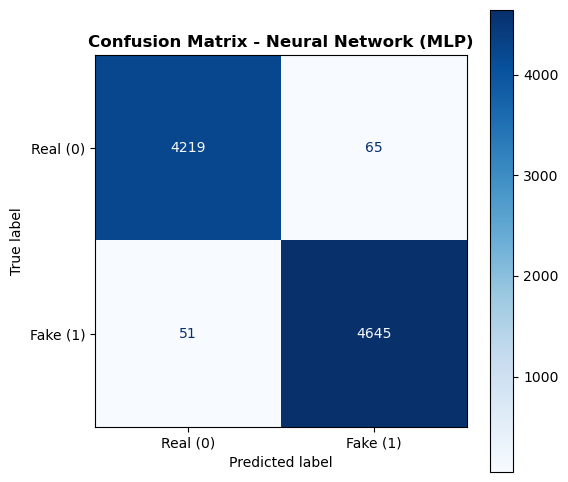

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

summary_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
summary_df = summary_df.sort_values(by='F1-Score', ascending=False)

best_model_name = summary_df.index[0]
best_model_data = results[best_model_name]
best_model = best_model_data['Model']
best_preds = best_model_data['Predictions']

print(f" EVALUATION METRICS FOR BEST MODEL: {best_model_name}")
print(f"Accuracy  : {best_model_data['Accuracy']:.4%}")
print(f"Precision : {best_model_data['Precision']:.4f}")
print(f"Recall    : {best_model_data['Recall']:.4f}")
print(f"F1-Score  : {best_model_data['F1-Score']:.4f}\n")

print("Detailed Classification Report:")
print(classification_report(y_test, best_preds, target_names=['Real (0)', 'Fake (1)']))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model, 
    X_test_emb, 
    y_test, 
    display_labels=['Real (0)', 'Fake (1)'],
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()

In [8]:
def predict_fake_news(text, model, embedding_model):
    cleanedText = clean_and_tokenization(text)
    text_embedding = embedding_model.encode([cleanedText])
    
    prediction = model.predict(text_embedding)[0]
    probabilities = model.predict_proba(text_embedding)[0]
    prob_real = probabilities[0] * 100
    prob_fake = probabilities[1] * 100

    label = "FAKE" if prediction == 1 else "REAL"
    confidence = prob_fake if prediction == 1 else prob_real
    
    print(f"Prediction  : {label}")
    print(f"Confidence  : {confidence:.2f}%")
    print(f"Breakdown   : {prob_real:.2f}% Chance Real | {prob_fake:.2f}% Chance Fake")
    print("=" * 60)

In [9]:
sample_real_1 = "The Watergate Scandal: In the 1970s, investigative journalists from The Washington Post uncovered a break-in at the Democratic National Committee headquarters. Their meticulously verified reporting exposed a massive political cover-up that ultimately led to the resignation of U.S. President Richard Nixon."
sample_real_2 = """Major Pipeline Operator Shuts Down Operations Following Ransomware AttackALPHARETTA, Ga. — One of the largest fuel pipeline operators in the United States announced on Saturday that it had halted all pipeline operations after falling victim to a sophisticated ransomware attack, raising concerns over regional energy infrastructure security.Colonial Pipeline, which transports approximately 45 percent of all fuel consumed on the East Coast, stated that the cybersecurity incident involved ransomware and was detected late Friday evening. In response, the company proactively took certain systems offline to contain the threat, temporarily pausing the transport of gasoline, diesel, and jet fuel across its 5,500-mile network. "We engaged a leading third-party cybersecurity firm to launch an investigation into the nature and scope of this attack," the company said in a public statement.Federal authorities, including the Cybersecurity and Infrastructure Security Agency (CISA) and the Department of Energy, are actively coordinating with the company to assess the economic impact. Industry analysts noted that while short-term outages are unlikely to cause immediate fuel shortages, prolonged downtime could lead to price fluctuations at retail gas stations. Law enforcement officials have tentatively attributed the attack to a known cybercriminal syndicate that specializes in data extortion."""
sample_real_3 = "LONDON - European central banks announced a joint policy initiative on Tuesday aimed at stabilizing energy markets and mitigating persistent inflation across the euro zone. The unified strategy includes targeted liquidity support for major utility suppliers, enhanced regulatory oversight on commodity trading derivatives, and coordinated interest rate adjustments designed to balance economic growth with price stability. Financial analysts at major global institutions noted that the announcement provided immediate relief to European financial markets, sending major stock indexes up by 1.8 percent in early trading. Representatives from the European Central Bank stated in a formal press briefing that these measures will remain active through the final quarter of the year to safeguard consumer purchasing power and strengthen supply chain resilience."

sample_fake_1 = """BOMBSHELL: NYPD Source Confirms FBI Raiding Clinton-Linked D.C. Pizzeria in Child Trafficking ProbeA massive underground operations ring involving top-tier Democratic officials has reportedly been uncovered in Washington, D.C., following a fresh batch of leaked emails from campaign chairman John Podesta. Independent whistleblowers analyzing the encrypted communications have cracked a sophisticated code hidden within mundane food orders.According to leaked files published by WikiLeaks, prominent political figures repeatedly used bizarre phrasing—including specific requests for "cheese pizza" and "handkerchief maps"—which intelligence insiders confirm are documented code words utilized by international human traffickers.High-level sources within the New York Police Department (NYPD) hint that a secret backroom raid is currently underway at Comet Ping Pong, a prominent family pizza parlor in the nation's capital. Local property records indicate the restaurant's owner maintains deep financial ties to elite political donors. Cyber investigators claim the building's hidden basement serves as the central hub for a highly coordinated, elite-led ring. While mainstream media networks maintain a strict blackout on the developing investigation, underground citizen journalists are urging the public to share this critical breakthrough before the evidence is permanently scrubbed from the internet."""
sample_fake_2 = "BREAKING EXCLUSIVE: Leaked Documents Confirm Secret Globalist Alliance Planning Total Cash Elimination by 2027! High-ranking whistleblowers inside top international banking institutions have just released thousands of encrypted emails revealing a top-secret initiative aimed at completely banning physical paper currency worldwide. According to the leaked files, corrupt corporate elites and unnamed global organizations plan to force all citizens onto a trackable digital-only banking system where every transaction will be monitored and restricted based on social compliance scores. Corporate media news outlets have strictly refused to cover this explosive story after receiving direct gag orders from government agencies. Independent researchers warn that unless patriotic citizens take immediate action to protest this agenda, individual financial freedom will vanish permanently overnight!"
sample_fake_3 = "INCRIMINATING EVIDENCE: Mainstream Media Caught Suppressing Secret Video Footage of Illegal Campaign Offsite! A shocking new viral video circulating on social media allegedly shows prominent political figures meeting behind closed doors at an undisclosed luxury resort to manipulate upcoming national election outcomes. Anonymous sources claim that millions of dollars in untraceable dark money were exchanged during the covert late-night session to finance smear campaigns and suppress opposing media outlets. Insiders reveal that several major news anchors were personally bribed to keep quiet and distract the public with fabricated political controversies. Despite overwhelming public outcry and millions of online views, top officials continue to deny the meeting took place and are demanding that social media platforms delete all footage immediately to cover up the scandal!"

test_samples = [
    {"id": "REAL_1", "expected": "REAL", "text": sample_real_1},
    {"id": "REAL_2", "expected": "REAL", "text": sample_real_2},
    {"id": "REAL_3", "expected": "REAL", "text": sample_real_3},
    {"id": "FAKE_1", "expected": "FAKE", "text": sample_fake_1},
    {"id": "FAKE_2", "expected": "FAKE", "text": sample_fake_2},
    {"id": "FAKE_3", "expected": "FAKE", "text": sample_fake_3}
]

for sample in test_samples:
    print(f"--- Sample ID: {sample['id']} (Expected: {sample['expected']}) ---")
    predict_fake_news(sample['text'], best_model, embedding_model)
    print("\n")

--- Sample ID: REAL_1 (Expected: REAL) ---
Prediction  : REAL
Confidence  : 70.34%
Breakdown   : 70.34% Chance Real | 29.66% Chance Fake


--- Sample ID: REAL_2 (Expected: REAL) ---
Prediction  : REAL
Confidence  : 99.21%
Breakdown   : 99.21% Chance Real | 0.79% Chance Fake


--- Sample ID: REAL_3 (Expected: REAL) ---
Prediction  : REAL
Confidence  : 100.00%
Breakdown   : 100.00% Chance Real | 0.00% Chance Fake


--- Sample ID: FAKE_1 (Expected: FAKE) ---
Prediction  : FAKE
Confidence  : 99.76%
Breakdown   : 0.24% Chance Real | 99.76% Chance Fake


--- Sample ID: FAKE_2 (Expected: FAKE) ---
Prediction  : FAKE
Confidence  : 100.00%
Breakdown   : 0.00% Chance Real | 100.00% Chance Fake


--- Sample ID: FAKE_3 (Expected: FAKE) ---
Prediction  : FAKE
Confidence  : 99.99%
Breakdown   : 0.01% Chance Real | 99.99% Chance Fake


